done:200/200


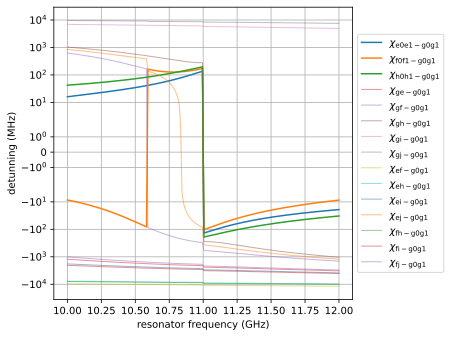

In [3]:
# sweep_resonator_frequency_for_ge_gf_gh_detunning(EJ=8.9,
#                                         EC=2.5,
#                                         EL=0.5,
#                                         flux = 0,
#                                         g_strength = 0.3,
#                                         osc_w_min= 10,
#                                         osc_w_max=12)

In [2]:
from utils import *


In [25]:
scqubits.GUI()

Container(children=[Sheet(children=[Card(children=[Img(layout=None, src='data:image/png;base64,iVBORw0KGgoAAAA…

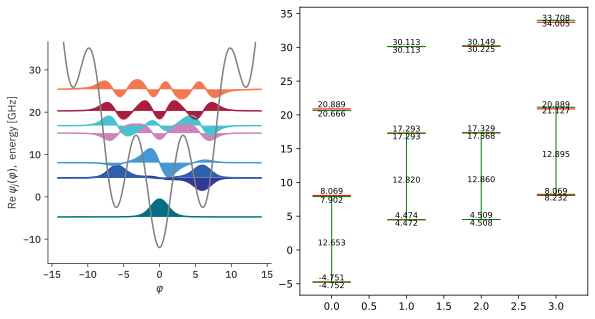

0.07580927516279345
0.11279379076862739
0.1472464151679489
0.17958097144524743
0.21012172629382064
0.23912481894996063
0.26679507144609715
0.29329844110904446
0.31877112448223954
0.34332623346114133
0.36705873796810806
0.3900491695295045
0.41236643195125566
0.4340699614081416
0.45521140673236005
0.47583595147199276
0.49598336525306763
0.5156888482339639
0.5349837156700517
0.5538959576604725
0.5724507004952102
0.5906705897576785
0.6085761106402288
0.62618585752341
0.6435167622136646
0.6605842879210968
0.6774023135930065
0.6938499710473138
0.6875296984694046


In [24]:


EJ=1
EC=2.5
EL=0.5
g_strength = 0.3

qubit_level = 15
osc_level =30

qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=30,truncated_dim=qubit_level)
E_osc = qbt.eigenvals()[3] - qbt.eigenvals()[0]

osc = scqubits.Oscillator(E_osc=E_osc,truncated_dim=osc_level)
hilbertspace = scqubits.HilbertSpace([qbt, osc])
hilbertspace.add_interaction(g_strength=g_strength,op1=qbt.n_operator,op2=osc.creation_operator,add_hc=True)
hilbertspace.generate_lookup()
product_to_dressed = generate_single_mapping(hilbertspace.hamiltonian())
plot_specturum(qbt, osc, hilbertspace)

energies=  hilbertspace.eigenvals(qubit_level*osc_level)
def stark(ql1,ql2,ol):
    return abs(energies[product_to_dressed[(ql2,ol)]]-energies[product_to_dressed[(ql1,ol)]])

for ol in range(1,osc_level):
    print(f"{stark(1,2,ol)}")

In [11]:
def lamb(ol1,ol2,ql):
    return abs(energies[product_to_dressed[(ql,ol2)]]-energies[product_to_dressed[(ql,ol1)]])
for ol2 in range(1,osc_level):
    print(f"{lamb(ol2-1,ol2,ql=0)}\t{lamb(ol2-1,ol2,ql=1)}\t{lamb(ol2-1,ol2,ql=2)}")

25.11923962965919	25.101562289657753	25.10199210743934
25.110021152986832	25.10156259201201	25.10199153711588
25.108263960043544	25.101562894075798	25.101990968182264
25.107352399055642	25.101563195849508	25.10199040063287
25.106769412433565	25.101563497333586	25.10198983446398
25.10635516750139	25.101563798528872	25.10198926967027
25.106041237492946	25.10156409943417	25.101988706248278
25.105792697612685	25.101564400053235	25.101988144192262
25.10558959076471	25.101564700381545	25.101987583497703
25.105419569400624	25.101565000424245	25.10198702415977
25.105274527699777	25.10156530017707	25.101986466176243
25.105148893949604	25.101565599645767	25.101985909539053
25.105038694774464	25.1015658988249	25.101985354248313
25.104941009932077	25.10156619772033	25.10198480029362
25.104853638523934	25.101566496327564	25.10198424767691
25.10477488605693	25.10156679465092	25.10198369638715
25.10470342382115	25.101567092687333	25.101983146427358
25.104638193242636	25.101567390439016	25.10198259778

10.0%. Run time:   1.57s. Est. time left: 00:00:00:14
20.0%. Run time:   2.80s. Est. time left: 00:00:00:11
30.0%. Run time:   4.05s. Est. time left: 00:00:00:09
40.0%. Run time:   5.33s. Est. time left: 00:00:00:07
50.0%. Run time:   6.60s. Est. time left: 00:00:00:06
60.0%. Run time:   7.85s. Est. time left: 00:00:00:05
70.0%. Run time:   9.10s. Est. time left: 00:00:00:03
80.0%. Run time:  10.34s. Est. time left: 00:00:00:02
90.0%. Run time:  11.77s. Est. time left: 00:00:00:01
Total run time:  13.09s
10.0%. Run time:   1.61s. Est. time left: 00:00:00:14
20.0%. Run time:   3.24s. Est. time left: 00:00:00:12
30.0%. Run time:   4.85s. Est. time left: 00:00:00:11
40.0%. Run time:   6.48s. Est. time left: 00:00:00:09
50.0%. Run time:   8.12s. Est. time left: 00:00:00:08
60.0%. Run time:   9.78s. Est. time left: 00:00:00:06
70.0%. Run time:  11.44s. Est. time left: 00:00:00:04
80.0%. Run time:  13.11s. Est. time left: 00:00:00:03
90.0%. Run time:  14.78s. Est. time left: 00:00:00:01
Tota

 /Users/jiakaiwang/opt/miniconda3/envs/tensorflow/lib/python3.10/site-packages/jax/_src/array.py: 343

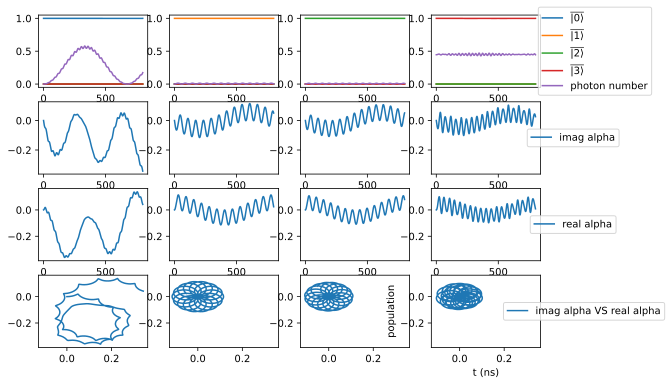

In [12]:
qubit_level = 5
osc_level = 6
qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=30,truncated_dim=qubit_level)

osc = scqubits.Oscillator(E_osc=E_osc,truncated_dim=osc_level)
hilbertspace = scqubits.HilbertSpace([qbt, osc])
hilbertspace.add_interaction(g_strength=g_strength,op1=qbt.n_operator,op2=osc.creation_operator,add_hc=True)
hilbertspace.generate_lookup()
product_to_dressed = generate_single_mapping(hilbertspace.hamiltonian())



a = hilbertspace.op_in_dressed_eigenbasis(op=osc.annihilation_operator)
a = qutip.Qobj(a[:, :])
 
(evals,) = hilbertspace["evals"]
diag_dressed_hamiltonian = (
        2 * np.pi * qutip.Qobj(np.diag(evals),
        dims=[hilbertspace.subsystem_dims] * 2)
)
diag_dressed_hamiltonian = qutip.Qobj(diag_dressed_hamiltonian[:, :])

leakage_dressed_state_osc_0 = product_to_dressed[(0,0)]
leakage_dressed_state_osc_1 = product_to_dressed[(0,1)]
w_d = transition_frequency(hilbertspace,leakage_dressed_state_osc_0,leakage_dressed_state_osc_1 )


tot_time = 800
tlist = np.linspace(0, tot_time, tot_time*2)

A_square = 0.002

def square_cos(t,*args):
    cos = np.cos(w_d * 2*np.pi * t)
    return  2*np.pi *A_square * cos

H_with_drive = [
    diag_dressed_hamiltonian,
    [a+a.dag(), square_cos]]

kappa = 0.0
decay_term = kappa*a


results = []
for i in range(4):
    temp = solve_with_mesolve(
        H = H_with_drive,
        state0=  qutip.basis(hilbertspace.dimension, product_to_dressed[(i,0)]),
        tlist = tlist,
        # c_ops= [ decay_term],
        options=qutip.Options(store_states=True,nsteps=20000,num_cpus = 7),
        
    )
    results.append(temp)


plot_population(results,qubit_level,osc_level,product_to_dressed,a,w_d,tlist,fourier=True)

In [49]:
interactive_heatmap(results[0], product_to_dressed, qubit_levels=qubit_level, oscillator_levels=osc_level)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Time Index:', max=1599), Output…